# **Seasonal Agriculture Performance Analysis**

### **1. Dataset Information**

The dataset contains **4,000 agricultural records and 28 variables**. It includes information about states, districts, crops, seasons, irrigation methods, yield, production, revenue, cost, profit, water usage, environmental conditions, soil properties, fertilizer usage and disease/pest risk. The dataset covers **Kharif, Rabi and Zaid** seasons.

### **2. Problem Statement**

Agricultural performance varies across different seasons due to changes in environmental conditions, crop types, irrigation, resource usage and market factors. The project aims to analyze these variations and identify important patterns, trends and relationships in agricultural performance.

### **3. Need of the Analysis**

The analysis is needed to understand seasonal crop performance, resource usage, environmental effects and economic outcomes. It helps in identifying better-performing seasons and crops and supports data-based agricultural planning.

### **4. Importance of the Project**

The project helps to compare seasonal performance, understand crop and regional differences, analyze water and resource usage, study profitability and identify important agricultural patterns for better decision-making.


## **1. Basic Libraries and Upload Information**

**1.1. Install/Import Libraries**

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


**1.2. Upload Dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

print("Dataset uploaded successfully!")

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv
Dataset uploaded successfully!


**1.3. Load Dataset**

In [ ]:
# Load CSV dataset

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


**1.4. First 10 Records**

In [ ]:


df.head(10)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3
5,SF10006,Gujarat,Raichur,Pulses,Zaid,5.46,356.0,33.6,49.0,8.3,...,0.89,0.72,3.93,68593,302333,269570,-32763,1093,3.596,57.1
6,SF10007,Telangana,Warangal,Wheat,Rabi,8.13,432.2,23.5,50.8,9.5,...,0.87,2.53,20.57,22951,513341,472102,-41239,2368,8.687,31.6
7,SF10008,Tamil Nadu,Ludhiana,Pulses,Kharif,5.34,860.2,29.0,64.9,7.9,...,0.70,1.18,6.30,70042,436200,441265,5065,1704,3.697,54.2
8,SF10009,Karnataka,Guntur,Cotton,Zaid,6.98,624.7,33.4,46.8,7.9,...,0.88,1.53,10.68,70771,525129,755834,230705,5079,2.103,54.7
9,SF10010,Tamil Nadu,Raichur,Chilli,Rabi,13.69,415.8,22.3,57.3,8.6,...,0.70,2.29,31.35,94383,1004072,2958907,1954835,5984,5.239,41.7


**1.5. Last 10 Records**

In [ ]:
df.tail(10)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3990,SF13991,Tamil Nadu,Indore,Cotton,Kharif,6.58,1072.3,28.0,79.6,7.3,...,0.70,1.62,10.66,72931,388777,777444,388667,6259,1.703,41.1
3991,SF13992,Telangana,Rajkot,Chilli,Zaid,2.04,338.8,34.4,69.0,7.5,...,0.82,1.07,2.18,80847,137231,176246,39015,854,2.553,41.8
3992,SF13993,Karnataka,Rajkot,Groundnut,Rabi,2.03,579.9,20.4,56.5,8.0,...,0.66,1.61,3.27,58117,139340,190043,50703,1416,2.309,38.6
3993,SF13994,Gujarat,Rajkot,Cotton,Rabi,13.48,308.9,25.0,70.8,8.1,...,0.89,1.33,17.93,71268,1053465,1277835,224370,10589,1.693,43.7
3994,SF13995,Maharashtra,Ludhiana,Wheat,Kharif,9.20,1243.8,27.5,66.5,7.4,...,0.70,2.18,20.06,23314,618838,467679,-151159,5577,3.597,67.1
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


**1.6. Dataset Shape**

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4000
Columns: 28


**1.7. Column Names**

In [ ]:
print("Column names:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

Column names:

1 - Farm_ID
2 - State
3 - District
4 - Crop
5 - Season
6 - Farm_Area_Hectares
7 - Rainfall_mm
8 - Avg_Temperature_C
9 - Humidity_pct
10 - Sunlight_Hours_Day
11 - Soil_pH
12 - Soil_Moisture_pct
13 - Nitrogen_kg_ha
14 - Phosphorus_kg_ha
15 - Potassium_kg_ha
16 - Irrigation_Method
17 - Fertilizer_kg_ha
18 - Pesticide_Litre_ha
19 - Seed_Quality_Score
20 - Yield_Tonnes_Ha
21 - Production_Tonnes
22 - Market_Price_INR_Tonne
23 - Total_Cost_INR
24 - Revenue_INR
25 - Profit_INR
26 - Water_Used_m3
27 - Water_Efficiency_t_per_1000m3
28 - Disease_Pest_Risk_pct


**1.8. Dataset Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

**1.9. Statistical Summary**

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


**1.10. Categorical Summary**

In [ ]:
df.describe(include='object')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


# **2. DATA CLEANING**

**2.1. Missing Values**

In [ ]:
# Check missing values

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Values': missing_values.values
})

missing_table = missing_table.sort_values(
    by='Missing_Values',
    ascending=False
)

missing_table

,Column,Missing_Values
6,Rainfall_mm,48
11,Soil_Moisture_pct,40
19,Yield_Tonnes_Ha,32
0,Farm_ID,0
3,Crop,0
2,District,0
5,Farm_Area_Hectares,0
4,Season,0
7,Avg_Temperature_C,0
8,Humidity_pct,0


**2.2. Missing Value Percentage**

In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage.sort_values(
    ascending=False
)

missing_percentage

,0
Rainfall_mm,1.2
Soil_Moisture_pct,1.0
Yield_Tonnes_Ha,0.8
Farm_ID,0.0
Crop,0.0
District,0.0
Farm_Area_Hectares,0.0
Season,0.0
Avg_Temperature_C,0.0
Humidity_pct,0.0


**2.3. Duplicate Records**

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


**2.4. Remove Duplicates**

In [ ]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (4000, 28)


**2.5. Check Data Types**

In [ ]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


**2.6. Check Unique Values**

In [ ]:
for column in df.select_dtypes(include='object').columns:
    print("\n", column)
    print(df[column].unique())


 Farm_ID
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

 State
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

 District
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

 Crop
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

 Season
['Kharif' 'Rabi' 'Zaid']

 Irrigation_Method
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


**2.7. Check Unique Values**

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

negative_values = {}

for column in numeric_columns:
    count = (df[column] < 0).sum()
    if count > 0:
        negative_values[column] = count

print("Negative values found:")
print(negative_values)

Negative values found:
{'Profit_INR': np.int64(1966)}


**2.8. Check Missing Values Again**

In [ ]:
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Total missing values: 120
Total duplicate rows: 0


## **3. BASIC EXPLORATORY DATA ANALYSIS**

**3.1. States**

In [ ]:
print("Number of states:", df['State'].nunique())

print("\nStates:")
print(df['State'].value_counts())

Number of states: 8

States:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64


**3.2. Districts**

In [ ]:
print("Number of districts:", df['District'].nunique())

print("\nTop 15 districts:")
print(df['District'].value_counts().head(15))

Number of districts: 10

Top 15 districts:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64


**3.3. Crops**

In [ ]:
print("Number of crops:", df['Crop'].nunique())

print("\nCrop distribution:")
print(df['Crop'].value_counts())

Number of crops: 8

Crop distribution:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


**3.4. Seasons**

In [ ]:
print("Number of seasons:", df['Season'].nunique())

print("\nSeason distribution:")
print(df['Season'].value_counts())

Number of seasons: 3

Season distribution:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


**3.5. Irrigation Methods**

In [ ]:
print("Irrigation methods:")

print(df['Irrigation_Method'].value_counts())

Irrigation methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


# **4. SEASON-WISE ANALYSI**









### **4.1.  Number of Farms per Season**

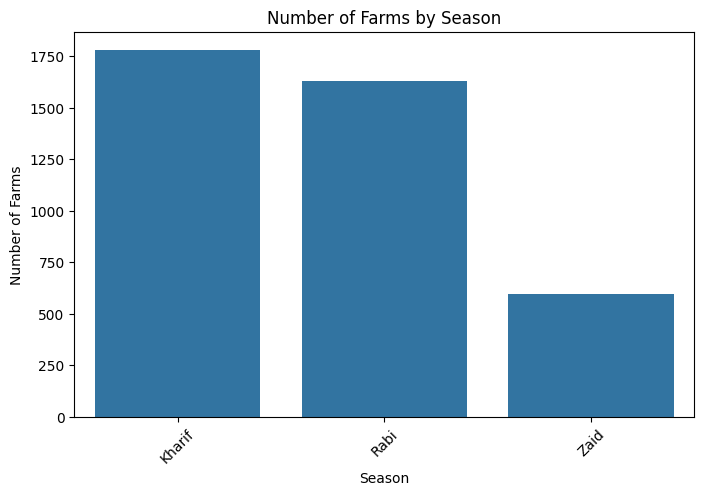

In [ ]:
season_count = df['Season'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_count.index,
    y=season_count.values
)

plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)

plt.show()

**4.2. Average Yield by Season**

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


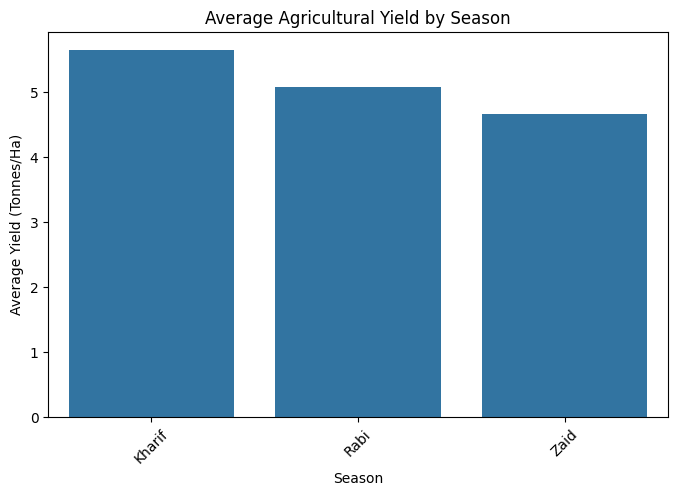

In [ ]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

print(season_yield)

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

**4.3. Production by Season**

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


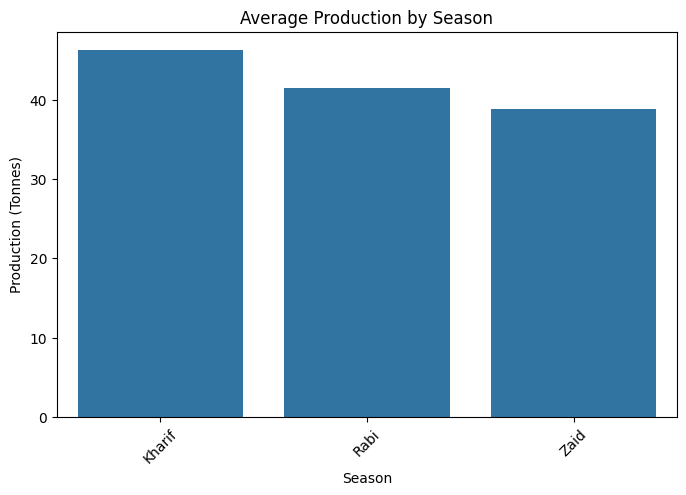

In [ ]:
season_production = df.groupby('Season')['Production_Tonnes'].mean().sort_values(
    ascending=False
)

print(season_production)

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_production.index,
    y=season_production.values
)

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")
plt.xticks(rotation=45)

plt.show()

**4.4. Revenue by Season**

Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64


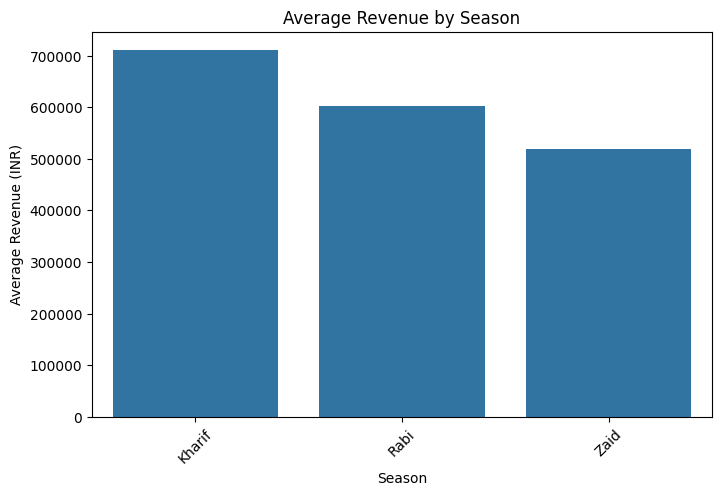

In [ ]:
season_revenue = df.groupby('Season')['Revenue_INR'].mean().sort_values(
    ascending=False
)

print(season_revenue)

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_revenue.index,
    y=season_revenue.values
)

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (INR)")
plt.xticks(rotation=45)

plt.show()

**4.5. Profit by Season**

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


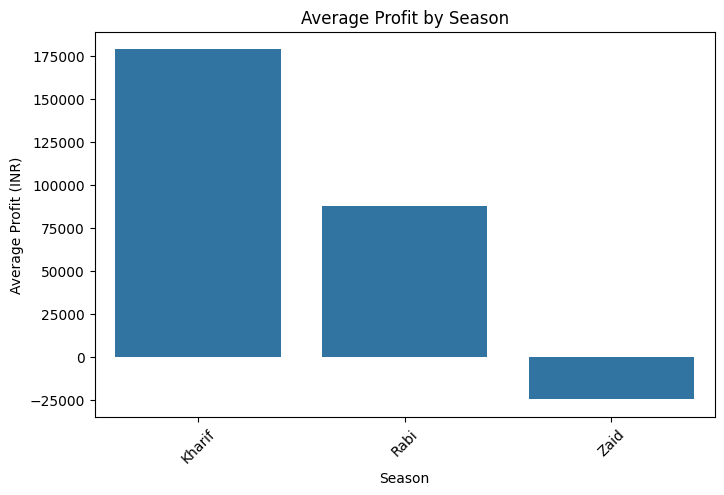

In [ ]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(
    ascending=False
)

print(season_profit)

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

**4.6. Cost by Season**

Season
Zaid      543976.728956
Kharif    531804.408094
Rabi      513836.578365
Name: Total_Cost_INR, dtype: float64


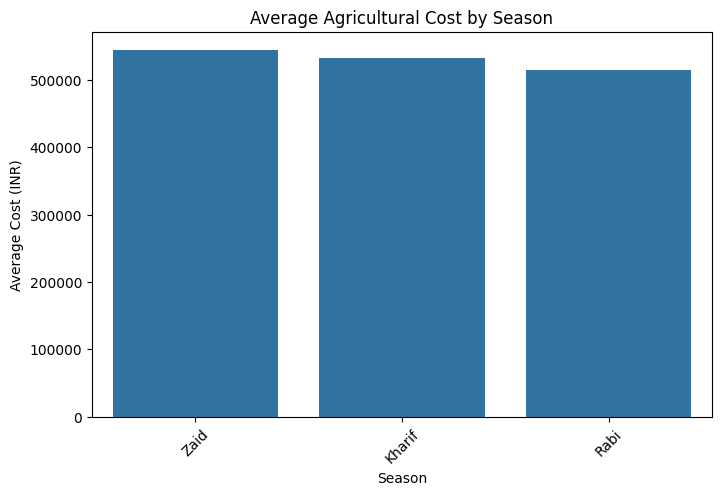

In [ ]:
season_cost = df.groupby('Season')['Total_Cost_INR'].mean().sort_values(
    ascending=False
)

print(season_cost)

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_cost.index,
    y=season_cost.values
)

plt.title("Average Agricultural Cost by Season")
plt.xlabel("Season")
plt.ylabel("Average Cost (INR)")
plt.xticks(rotation=45)

plt.show()

**4.7. Water Usage by Season**

Season
Zaid      6419.893939
Kharif    6102.201237
Rabi      5846.987093
Name: Water_Used_m3, dtype: float64


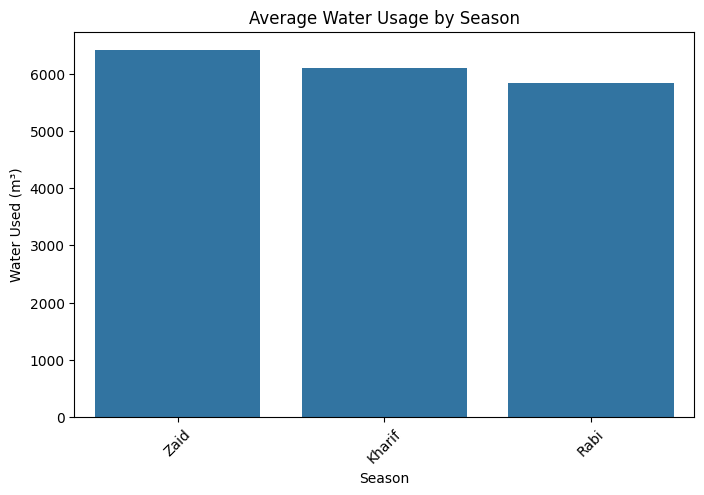

In [ ]:
season_water = df.groupby('Season')['Water_Used_m3'].mean().sort_values(
    ascending=False
)

print(season_water)

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_water.index,
    y=season_water.values
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=45)

plt.show()

**4.8. Disease/Pest Risk by Season**

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


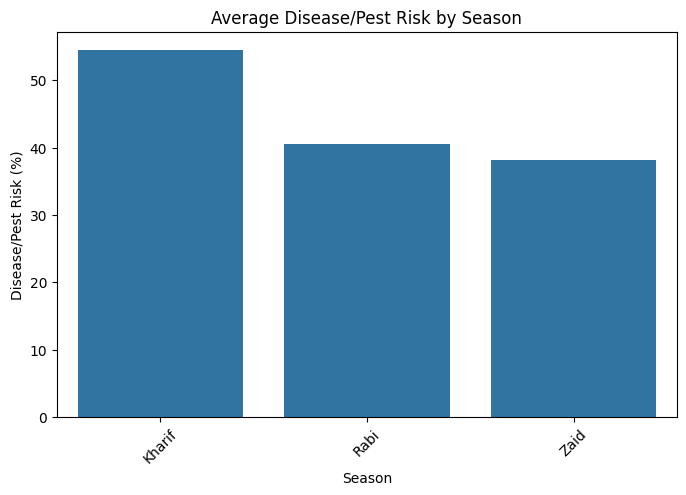

In [ ]:
season_risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().sort_values(
    ascending=False
)

print(season_risk)

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_risk.index,
    y=season_risk.values
)

plt.title("Average Disease/Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")
plt.xticks(rotation=45)

plt.show()

# **5. ENVIRONMENTAL CONDITIONS**

**5.1. Environmental Conditions by Season**

In [ ]:
environmental_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct'
]

environmental_by_season = df.groupby('Season')[environmental_columns].mean()

environmental_by_season

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,852.084205,28.454019,71.812591,6.793367,6.727993,31.198410
Rabi,436.000124,23.489183,57.893178,7.589797,6.673749,24.050620
Zaid,299.421784,31.042088,52.012121,8.178788,6.694865,19.170085


**5.2. Rainfall vs Yield**

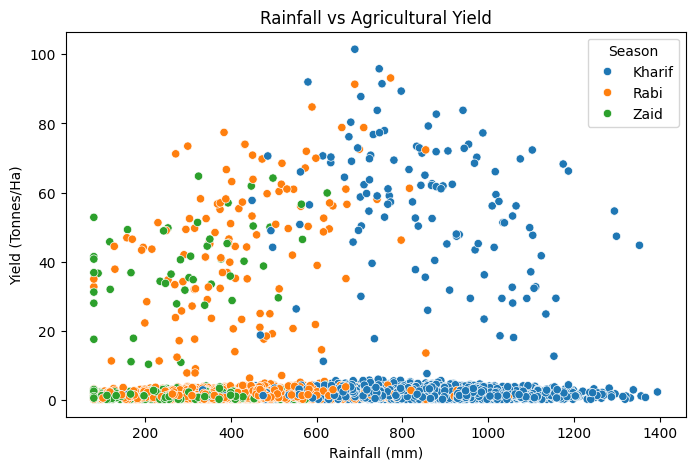

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

**5.3. Temperature vs Yield**

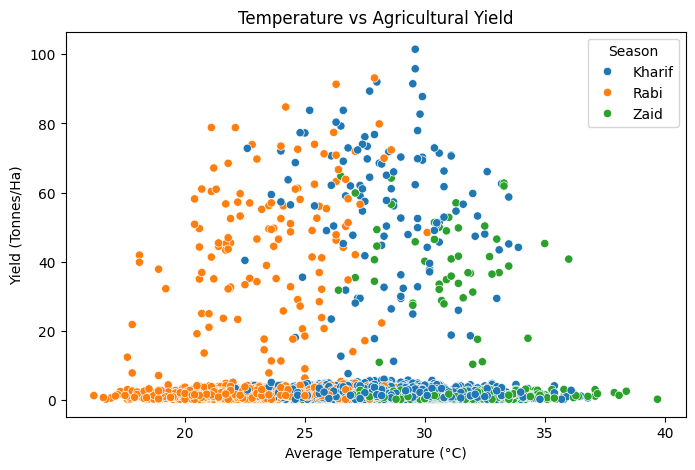

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Temperature vs Agricultural Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

**5.4. Humidity vs Yield**

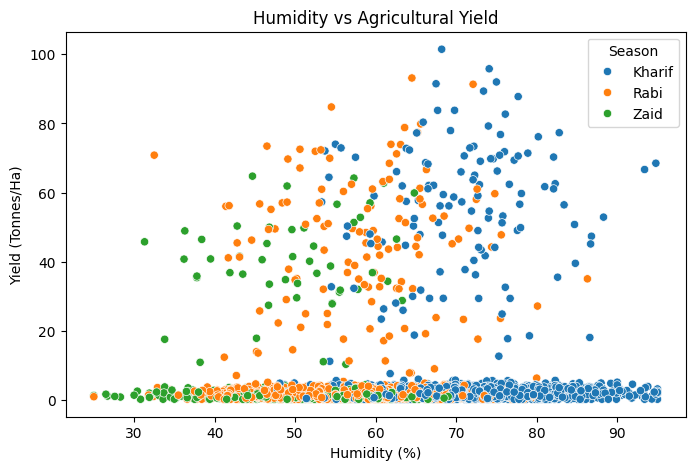

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Humidity_pct',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Humidity vs Agricultural Yield")
plt.xlabel("Humidity (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

**5.5. Soil Moisture vs Yield**

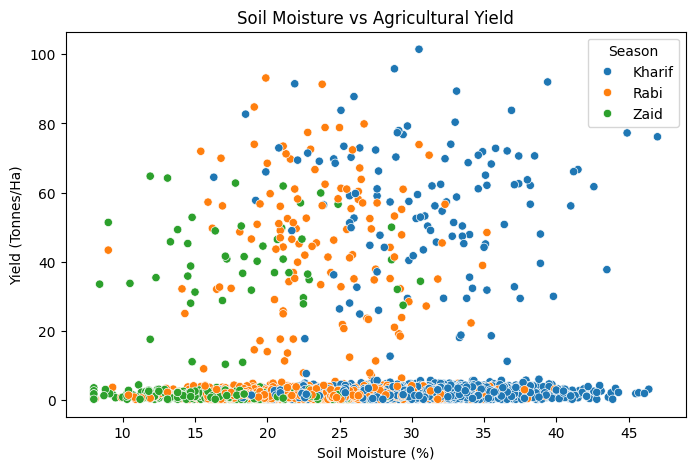

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Soil_Moisture_pct',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Soil Moisture vs Agricultural Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

**5.6. Soil pH vs Yield**

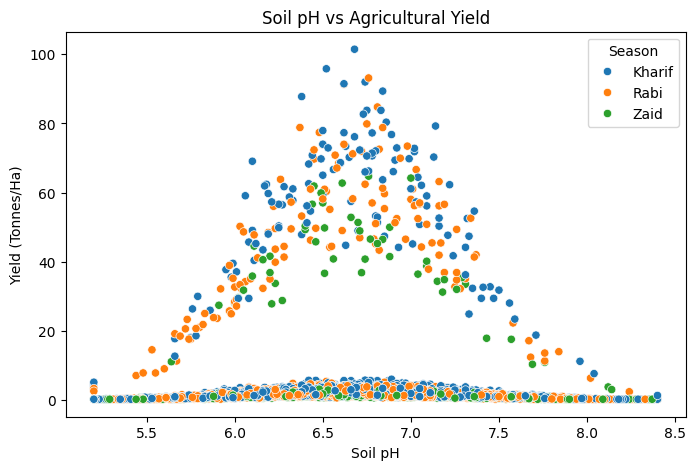

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Soil_pH',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Soil pH vs Agricultural Yield")
plt.xlabel("Soil pH")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

**5.7. Sunlight vs Yield**

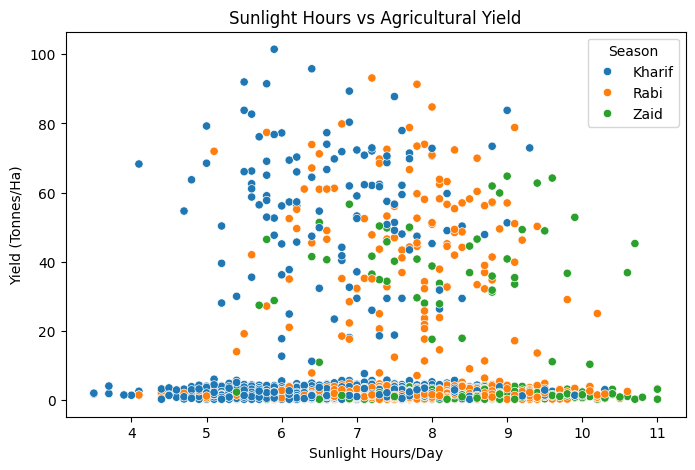

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Sunlight_Hours_Day',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Sunlight Hours vs Agricultural Yield")
plt.xlabel("Sunlight Hours/Day")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

# **6. RESOURCE USAGE ANALYSIS**

**6.1. Fertilizer vs Yield**

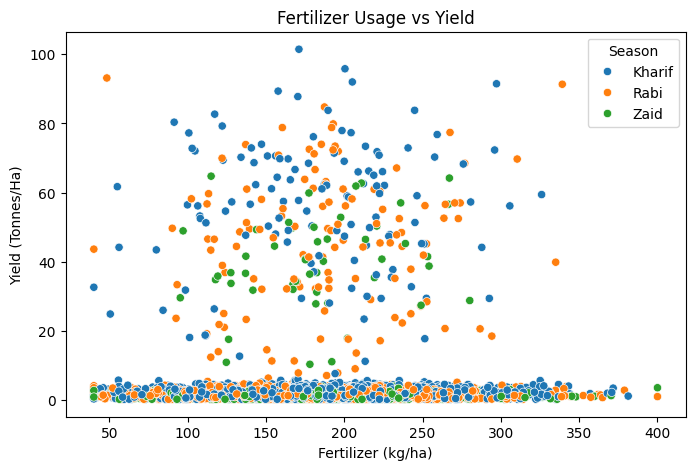

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Fertilizer Usage vs Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

**6.2. Nitrogen vs Yield**

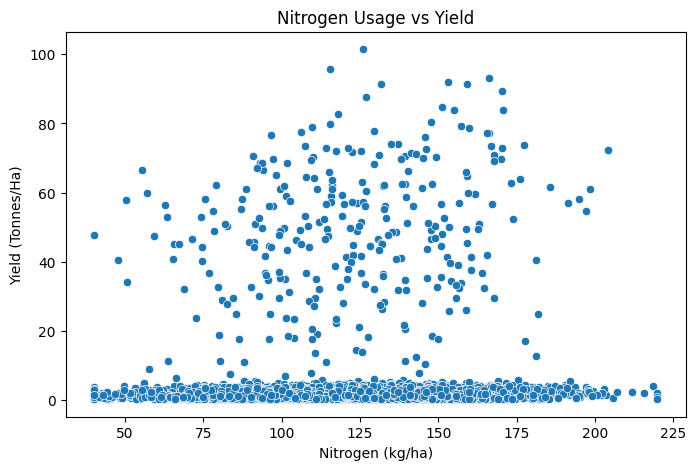

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Nitrogen_kg_ha',
    y='Yield_Tonnes_Ha'
)

plt.title("Nitrogen Usage vs Yield")
plt.xlabel("Nitrogen (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

**6.3. Phosphorus vs Yield**

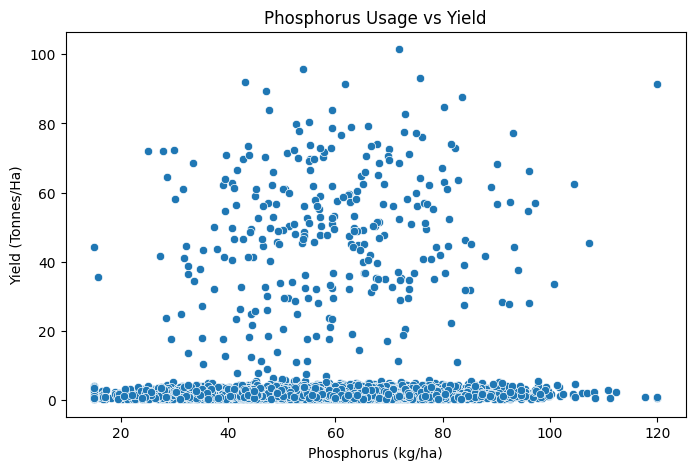

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Phosphorus_kg_ha',
    y='Yield_Tonnes_Ha'
)

plt.title("Phosphorus Usage vs Yield")
plt.xlabel("Phosphorus (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

**6.4. Potassium vs Yield**

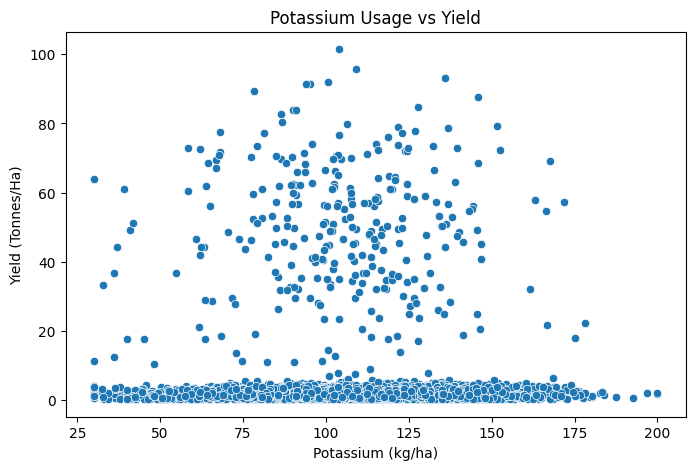

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Potassium_kg_ha',
    y='Yield_Tonnes_Ha'
)

plt.title("Potassium Usage vs Yield")
plt.xlabel("Potassium (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

**6.5. Irrigation Method vs Yield**

Irrigation_Method
Drip         6.620662
Sprinkler    5.188819
Flood        4.897724
Rainfed      4.613182
Name: Yield_Tonnes_Ha, dtype: float64


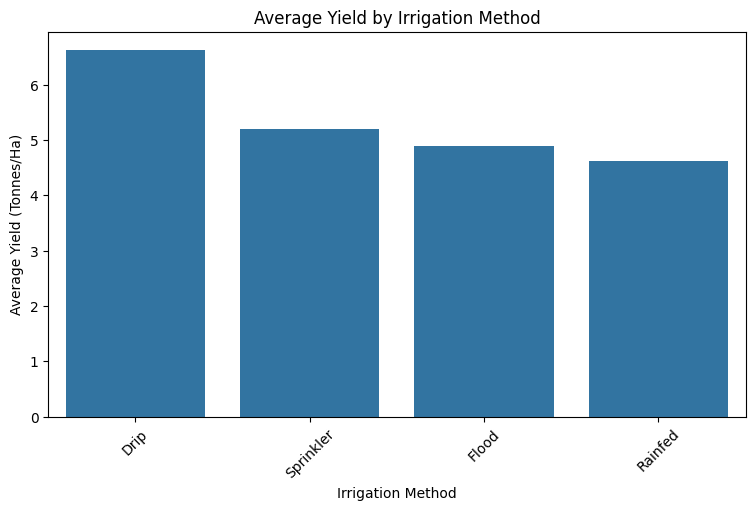

In [ ]:
irrigation_yield = df.groupby(
    'Irrigation_Method'
)['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print(irrigation_yield)

plt.figure(figsize=(9,5))

sns.barplot(
    x=irrigation_yield.index,
    y=irrigation_yield.values
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

**6.6. Water Usage vs Production**

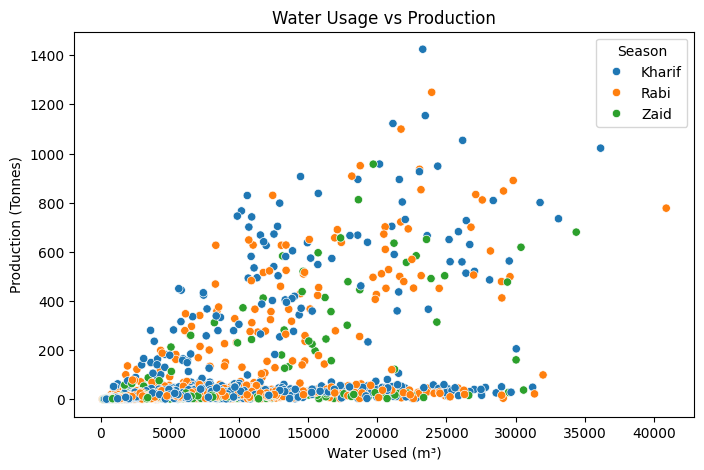

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Production_Tonnes',
    hue='Season'
)

plt.title("Water Usage vs Production")
plt.xlabel("Water Used (m³)")
plt.ylabel("Production (Tonnes)")

plt.show()

**6.7. Water Efficiency by Season**

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


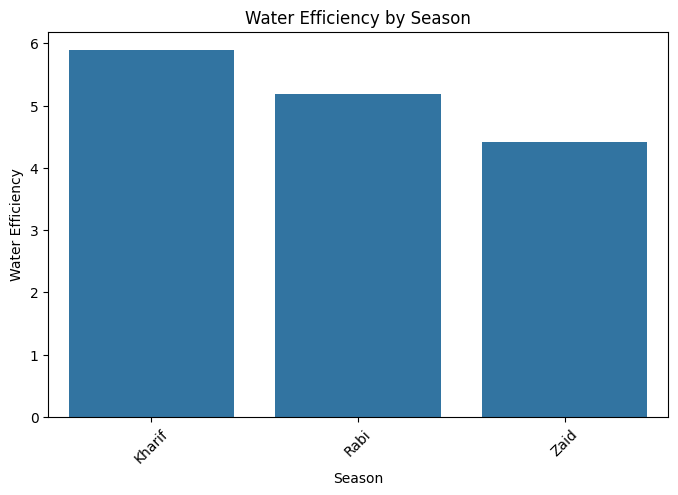

In [ ]:
water_efficiency = df.groupby(
    'Season'
)['Water_Efficiency_t_per_1000m3'].mean().sort_values(
    ascending=False
)

print(water_efficiency)

plt.figure(figsize=(8,5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")

plt.xticks(rotation=45)

plt.show()

# **7. CROP-WISE ANALYSIS**

**7.1. Average Yield by Crop**

Crop
Sugarcane    46.938746
Maize         2.717130
Rice          2.439413
Wheat         2.109216
Chilli        1.540344
Groundnut     1.317924
Cotton        1.225734
Pulses        0.918198
Name: Yield_Tonnes_Ha, dtype: float64


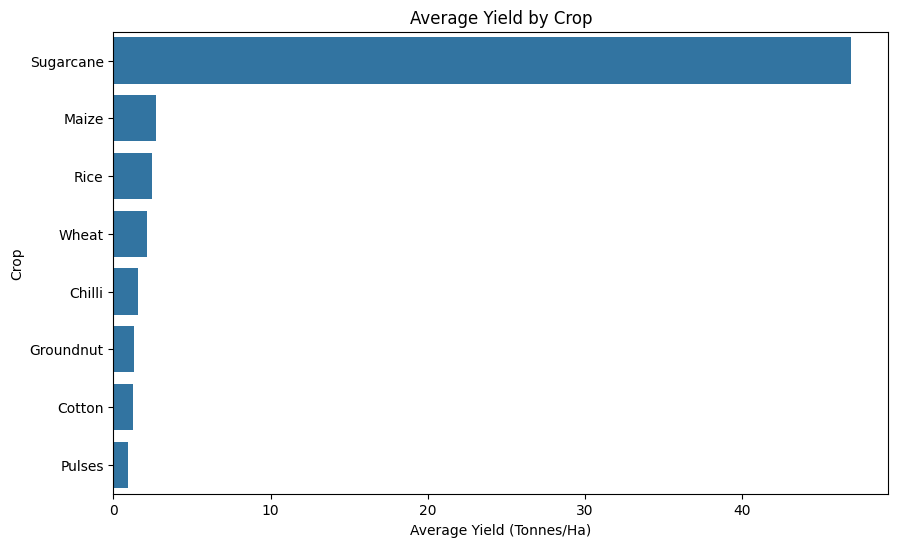

In [ ]:
crop_yield = df.groupby(
    'Crop'
)['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

print(crop_yield)

plt.figure(figsize=(10,6))

sns.barplot(
    x=crop_yield.values,
    y=crop_yield.index
)

plt.title("Average Yield by Crop")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("Crop")

plt.show()

**7.2. Crop Production**

In [ ]:
crop_production = df.groupby(
    'Crop'
)['Production_Tonnes'].mean().sort_values(
    ascending=False
)

print(crop_production)

**7.3. Crop Profitability**

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


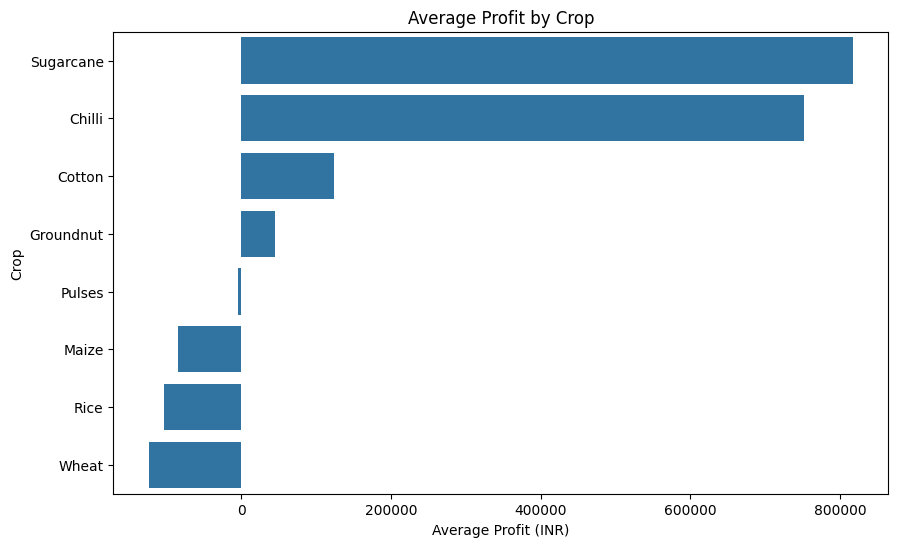

In [ ]:
crop_profit = df.groupby(
    'Crop'
)['Profit_INR'].mean().sort_values(
    ascending=False
)

print(crop_profit)

plt.figure(figsize=(10,6))

sns.barplot(
    x=crop_profit.values,
    y=crop_profit.index
)

plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")

plt.show()

**7.4. Crop Revenue**

In [ ]:
crop_revenue = df.groupby(
    'Crop'
)['Revenue_INR'].mean().sort_values(
    ascending=False
)

print(crop_revenue)

Crop
Sugarcane    1.371980e+06
Chilli       1.276777e+06
Cotton       6.394231e+05
Groundnut    5.429355e+05
Pulses       5.284659e+05
Maize        4.570680e+05
Rice         4.236153e+05
Wheat        4.001049e+05
Name: Revenue_INR, dtype: float64


# **8. STATE-WISE ANALYSIS**

**8.1. Yield by State**

State
Punjab            6.121116
Karnataka         5.734493
Gujarat           5.699586
Telangana         5.076810
Maharashtra       5.030333
Madhya Pradesh    5.029654
Tamil Nadu        4.901247
Andhra Pradesh    4.650781
Name: Yield_Tonnes_Ha, dtype: float64


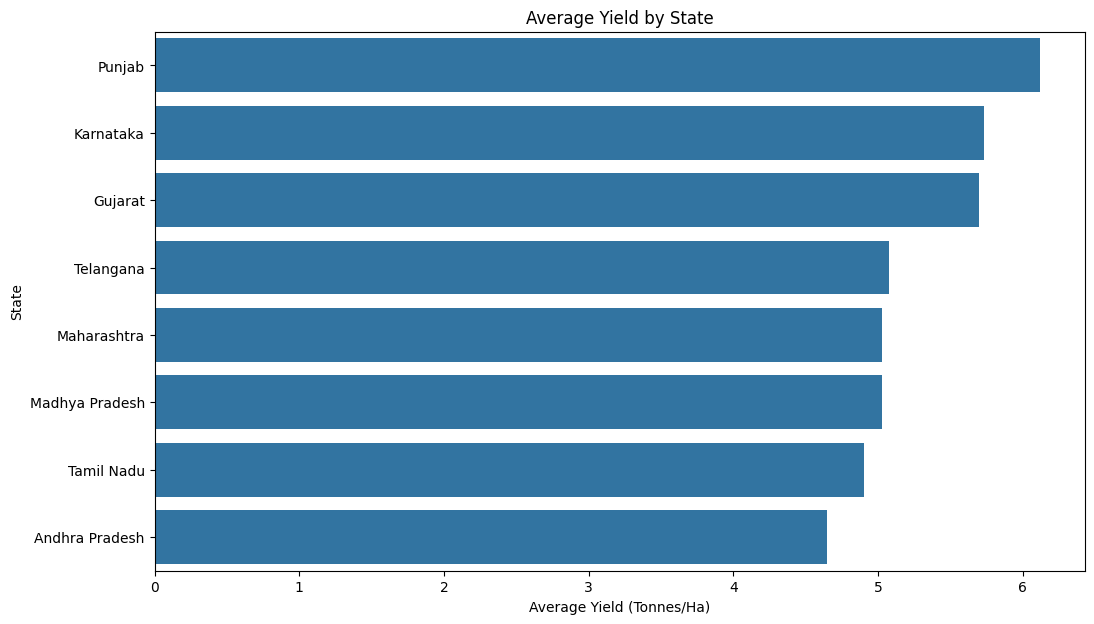

In [ ]:
state_yield = df.groupby(
    'State'
)['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

print(state_yield)

plt.figure(figsize=(12,7))

sns.barplot(
    x=state_yield.values,
    y=state_yield.index
)

plt.title("Average Yield by State")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")

plt.show()

**8.2. Profit by State**

State
Punjab            136025.636364
Maharashtra       135428.855469
Karnataka         119422.335378
Tamil Nadu        117744.748454
Gujarat           117568.235656
Telangana         108829.616279
Madhya Pradesh     86840.756539
Andhra Pradesh     73453.527410
Name: Profit_INR, dtype: float64


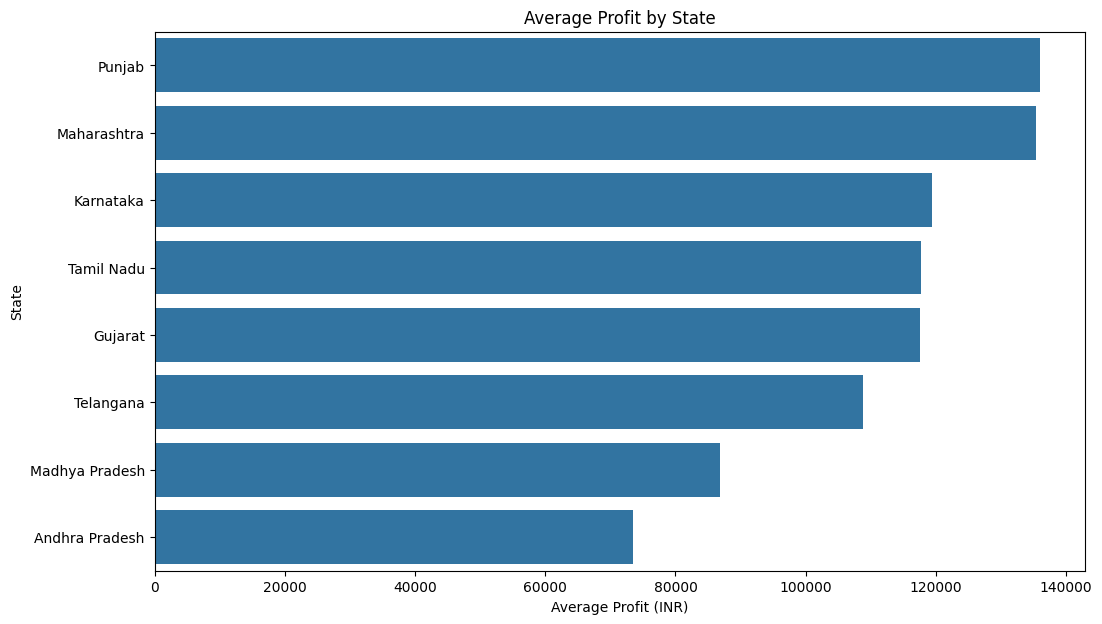

In [ ]:
state_profit = df.groupby(
    'State'
)['Profit_INR'].mean().sort_values(
    ascending=False
)

print(state_profit)

plt.figure(figsize=(12,7))

sns.barplot(
    x=state_profit.values,
    y=state_profit.index
)

plt.title("Average Profit by State")
plt.xlabel("Average Profit (INR)")
plt.ylabel("State")

plt.show()

# **9. SEASON × CROP ANALYSIS**

**9.1. Season and Crop Yield**

In [ ]:
season_crop_yield = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

season_crop_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731413,1.461615,1.177742
Cotton,1.372804,1.192915,0.951648
Groundnut,1.483646,1.221445,1.037778
Maize,2.966410,2.614913,2.297590
Pulses,1.036063,0.871887,0.652131
Rice,2.707621,2.333680,1.900490
Sugarcane,53.459120,43.940394,38.423922
Wheat,2.255430,2.058814,1.748588


**9.2. Heatmap**

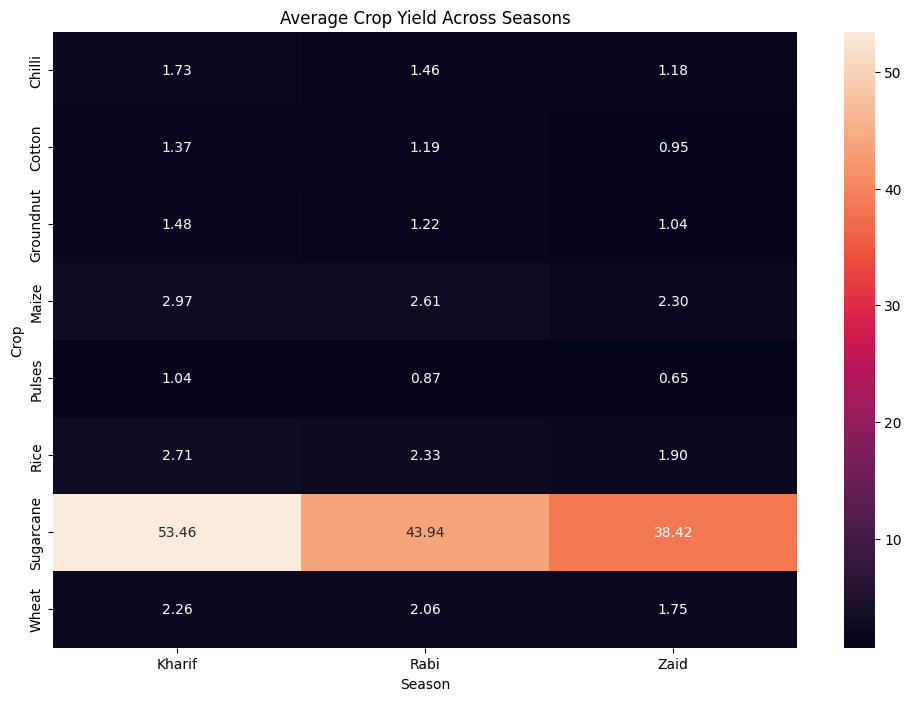

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    season_crop_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

**9.3. Season × Irrigation**

In [ ]:
season_irrigation = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Irrigation_Method',
    columns='Season',
    aggfunc='mean'
)

season_irrigation

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,7.256296,6.208287,5.848143
Flood,5.000017,5.098904,4.031632
Rainfed,5.721193,3.939151,3.063786
Sprinkler,4.671375,5.356609,6.172773


**9.4. Irrigation Heatmap**

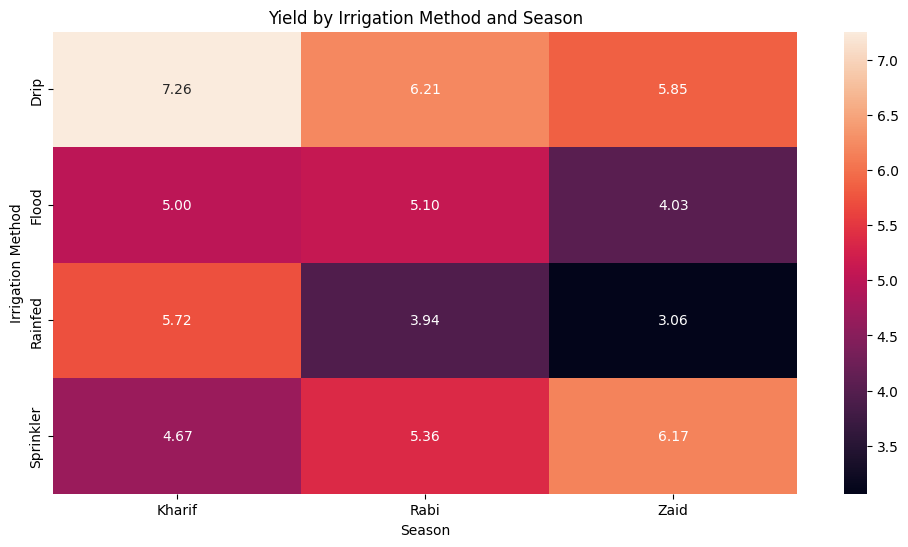

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(
    season_irrigation,
    annot=True,
    fmt=".2f"
)

plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")

plt.show()

# **10. CORRELATION ANALYSIS**

 **10.1. Correlation Matrix**

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct
Farm_Area_Hectares,1.000000,0.007384,0.036870,0.000471,0.001821,0.009857,0.004079,0.013658,-0.006625,0.000195,...,0.030188,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963,-0.001620
Rainfall_mm,0.007384,1.000000,0.200020,0.523966,-0.364748,0.016742,0.515751,0.007620,0.021175,0.031655,...,0.030853,0.024551,0.000525,0.013173,0.098652,0.108104,0.002324,0.058473,0.625071,0.060254
Avg_Temperature_C,0.036870,0.200020,1.000000,0.138136,-0.033863,0.029988,0.084492,0.018707,0.008508,0.022993,...,0.009349,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613,-0.007474
Humidity_pct,0.000471,0.523966,0.138136,1.000000,-0.297298,0.028447,0.448717,0.001198,-0.005963,-0.003070,...,0.011277,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093,0.028930
Sunlight_Hours_Day,0.001821,-0.364748,-0.033863,-0.297298,1.000000,-0.017806,-0.304221,0.009920,0.001544,-0.014407,...,-0.015362,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251,-0.036717
Soil_pH,0.009857,0.016742,0.029988,0.028447,-0.017806,1.000000,0.031345,0.006286,0.016620,-0.019407,...,-0.020664,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141,-0.005132
Soil_Moisture_pct,0.004079,0.515751,0.084492,0.448717,-0.304221,0.031345,1.000000,0.008898,0.013455,0.007874,...,0.010210,0.004848,0.016942,0.002789,0.079779,0.091757,0.003276,0.027892,0.376947,0.052198
Nitrogen_kg_ha,0.013658,0.007620,0.018707,0.001198,0.009920,0.006286,0.008898,1.000000,0.010199,0.010490,...,0.053867,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503,0.040950
Phosphorus_kg_ha,-0.006625,0.021175,0.008508,-0.005963,0.001544,0.016620,0.013455,0.010199,1.000000,0.002847,...,0.047821,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061,0.052533
Potassium_kg_ha,0.000195,0.031655,0.022993,-0.003070,-0.014407,-0.019407,0.007874,0.010490,0.002847,1.000000,...,0.003836,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403,0.006412


**10.2. Correlation Heatmap**

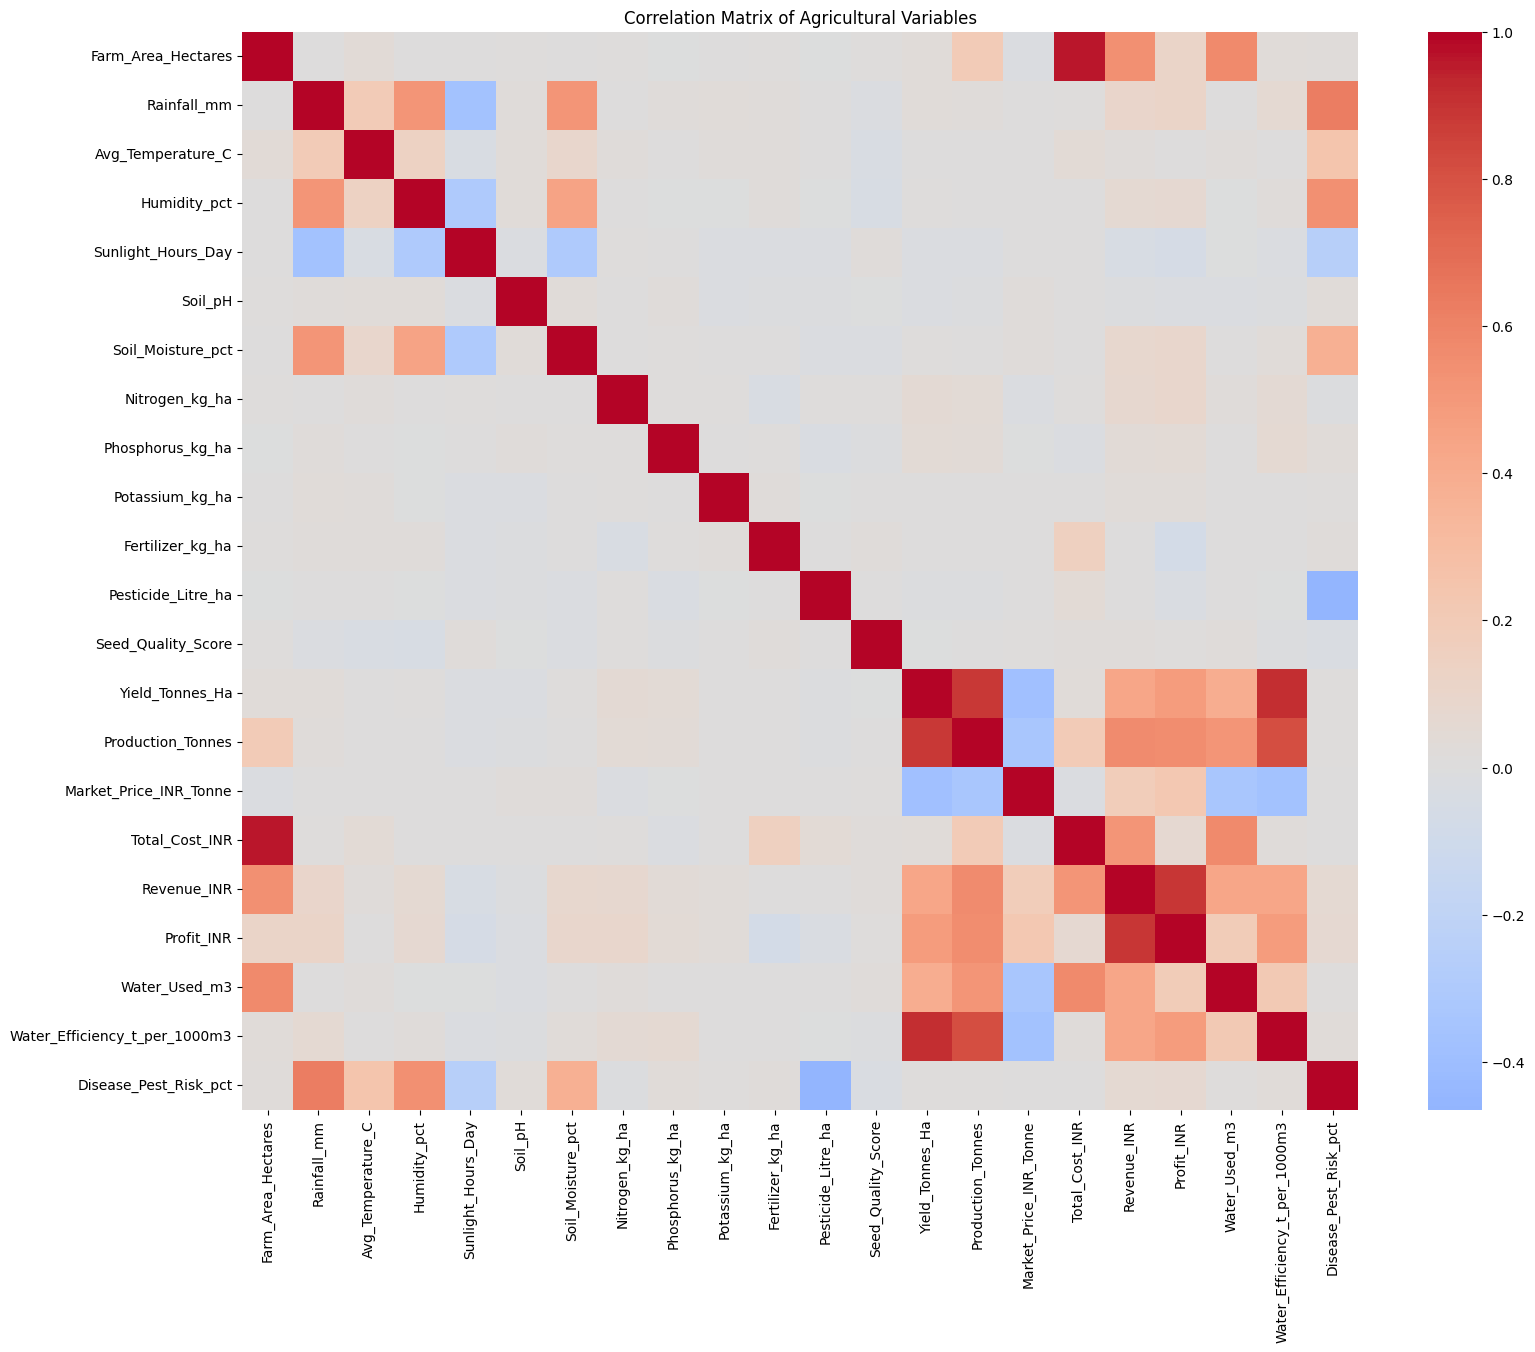

In [ ]:
plt.figure(figsize=(18,14))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.show()

**10.3. Yield Correlations**

In [ ]:
yield_correlations = correlation_matrix[
    'Yield_Tonnes_Ha'
].sort_values(
    ascending=False
)

print("Variables positively/negatively related to Yield:")
print(yield_correlations)

Variables positively/negatively related to Yield:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Profit_INR                       0.489822
Revenue_INR                      0.433648
Water_Used_m3                    0.388653
Nitrogen_kg_ha                   0.053867
Phosphorus_kg_ha                 0.047821
Rainfall_mm                      0.030853
Total_Cost_INR                   0.030814
Farm_Area_Hectares               0.030188
Disease_Pest_Risk_pct            0.013490
Humidity_pct                     0.011277
Soil_Moisture_pct                0.010210
Avg_Temperature_C                0.009349
Potassium_kg_ha                  0.003836
Fertilizer_kg_ha                 0.000562
Seed_Quality_Score              -0.006737
Pesticide_Litre_ha              -0.007650
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020664
Market_Price_INR_Tonne          -0.384307
Name: Yield_Tonnes_Ha, dty

**10.4. Profit Correlations**

In [ ]:
profit_correlations = correlation_matrix[
    'Profit_INR'
].sort_values(
    ascending=False
)

print("Variables related to Profit:")
print(profit_correlations)

Variables related to Profit:
Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Yield_Tonnes_Ha                  0.489822
Water_Efficiency_t_per_1000m3    0.489487
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.108104
Soil_Moisture_pct                0.091757
Nitrogen_kg_ha                   0.085016
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64


# **11. DISTRIBUTION ANALYSIS**

**11.1. Yield Distribution**

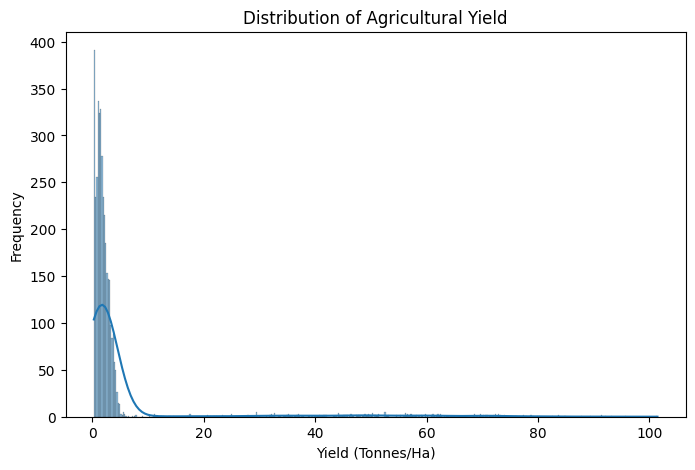

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Yield_Tonnes_Ha'],
    kde=True
)

plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")

plt.show()

**11.2. Profit Distribution**

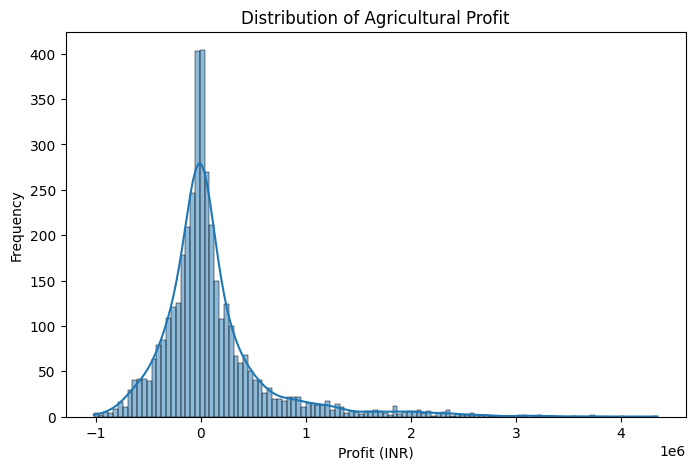

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Profit_INR'],
    kde=True
)

plt.title("Distribution of Agricultural Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")

plt.show()

# **12. OUTLIER ANALYSIS**

**12.1. Yield Boxplot**

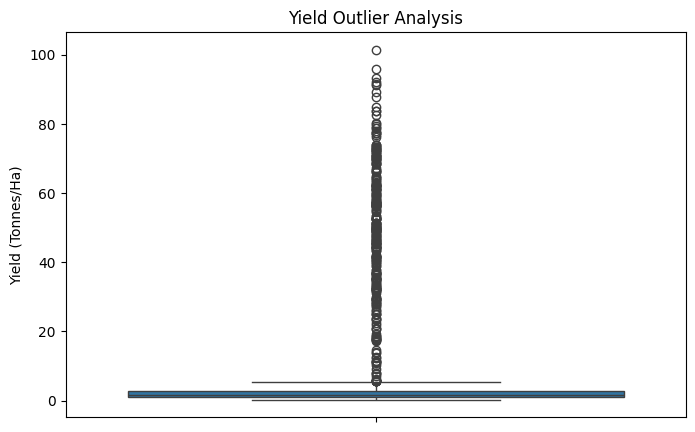

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['Yield_Tonnes_Ha']
)

plt.title("Yield Outlier Analysis")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

**12.2 Profit Boxplot by Season**

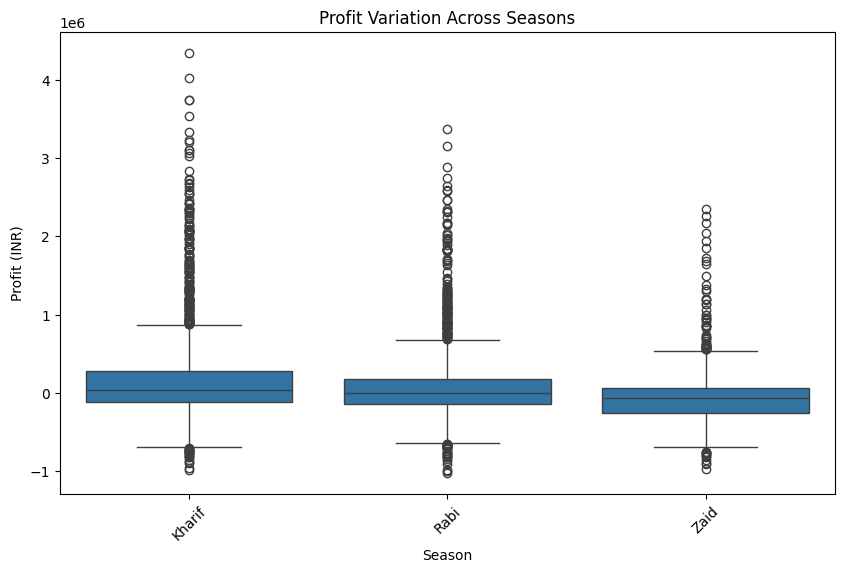

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title("Profit Variation Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.xticks(rotation=45)

plt.show()

# **13. STATISTICAL ANALYSIS**

**13.1. Season vs Yield — ANOVA**

In [ ]:
# Separate yield values for each season

season_groups = [
    group['Yield_Tonnes_Ha'].dropna().values
    for name, group in df.groupby('Season')
]

anova_result = stats.f_oneway(*season_groups)

print("ANOVA Test Result")
print("-----------------")
print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("\nResult: Significant difference exists between seasonal yields.")
else:
    print("\nResult: No statistically significant difference detected between seasonal yields.")

ANOVA Test Result
-----------------
F-statistic: 1.4579589466621523
P-value: 0.23283549440109827

Result: No statistically significant difference detected between seasonal yields.


**13.2. SEASON vs PROFIT**

In [ ]:
profit_groups = [
    group['Profit_INR'].dropna().values
    for name, group in df.groupby('Season')
]

anova_profit = stats.f_oneway(*profit_groups)

print("ANOVA Test for Seasonal Profit")
print("--------------------------------")
print("F-statistic:", anova_profit.statistic)
print("P-value:", anova_profit.pvalue)

if anova_profit.pvalue < 0.05:
    print("\nResult: Seasonal profit differences are statistically significant.")
else:
    print("\nResult: Seasonal profit differences are not statistically significant.")

ANOVA Test for Seasonal Profit
--------------------------------
F-statistic: 34.29175033935195
P-value: 1.7124156677360182e-15

Result: Seasonal profit differences are statistically significant.


# **14. PEARSON CORRELATION**

**14.1. Important Relationships**

In [ ]:
variables = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Water_Used_m3',
    'Yield_Tonnes_Ha'
]

correlation_results = []

for variable in variables:

    if variable != 'Yield_Tonnes_Ha':

        r, p = stats.pearsonr(
            df[variable],
            df['Yield_Tonnes_Ha']
        )

        correlation_results.append([
            variable,
            r,
            p
        ])

correlation_results = pd.DataFrame(
    correlation_results,
    columns=[
        'Variable',
        'Pearson_Correlation',
        'P_Value'
    ]
)

correlation_results.sort_values(
    'Pearson_Correlation',
    ascending=False
)

,Variable,Pearson_Correlation,P_Value
0,Rainfall_mm,NaN,NaN
1,Avg_Temperature_C,NaN,NaN
2,Humidity_pct,NaN,NaN
3,Sunlight_Hours_Day,NaN,NaN
4,Soil_pH,NaN,NaN
5,Soil_Moisture_pct,NaN,NaN
6,Fertilizer_kg_ha,NaN,NaN
7,Water_Used_m3,NaN,NaN


 **15. ECONOMIC ANALYSIS**

**15.1. Profit Margin**

In [ ]:
df['Profit_Margin_pct'] = (
    df['Profit_INR'] / df['Revenue_INR']
) * 100

df[['Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']].head()

,Revenue_INR,Profit_INR,Profit_Margin_pct
0,30810,-11852,-38.468030
1,40401,-451950,-1118.660429
2,190466,-124744,-65.494104
3,200740,-95704,-47.675600
4,193607,-144352,-74.559288


**15.2. Average Profit Margin by Season**

Season
Kharif   -38.644541
Rabi     -44.267645
Zaid     -69.354573
Name: Profit_Margin_pct, dtype: float64


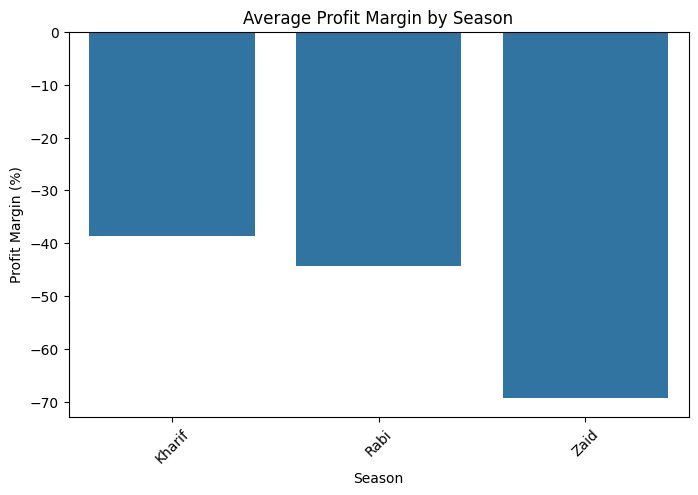

In [ ]:
season_margin = df.groupby(
    'Season'
)['Profit_Margin_pct'].mean().sort_values(
    ascending=False
)

print(season_margin)

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_margin.index,
    y=season_margin.values
)

plt.title("Average Profit Margin by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)

plt.show()

**15.3. Market Price by Crop**

Crop
Chilli       103372.941748
Pulses        71431.608871
Cotton        67921.108268
Groundnut     56310.061321
Wheat         23829.425081
Rice          22023.128986
Maize         20990.549909
Sugarcane      3490.252459
Name: Market_Price_INR_Tonne, dtype: float64


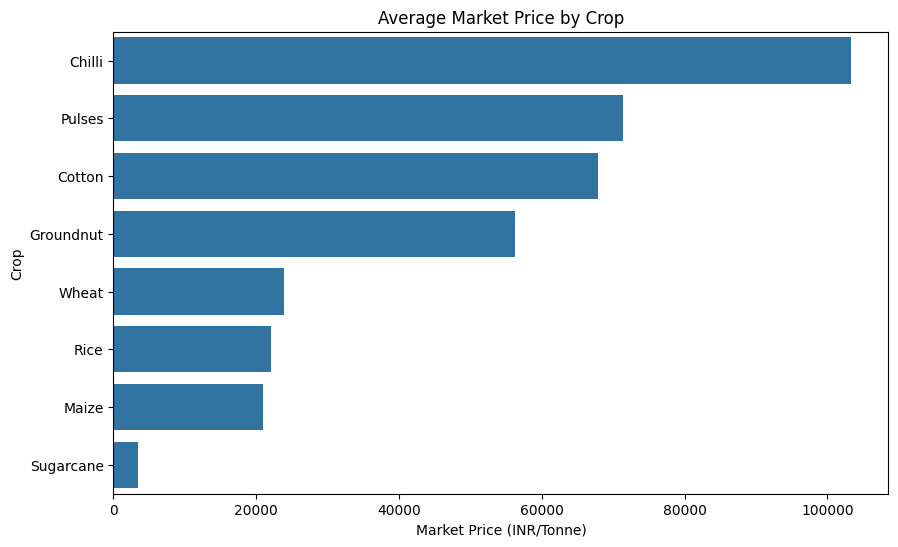

In [ ]:
market_price = df.groupby(
    'Crop'
)['Market_Price_INR_Tonne'].mean().sort_values(
    ascending=False
)

print(market_price)

plt.figure(figsize=(10,6))

sns.barplot(
    x=market_price.values,
    y=market_price.index
)

plt.title("Average Market Price by Crop")
plt.xlabel("Market Price (INR/Tonne)")
plt.ylabel("Crop")

plt.show()

# **16. TOP PERFORMERS**

**16.1. Best Season**

In [ ]:
best_season = season_yield.idxmax()
best_yield = season_yield.max()

print("Best performing season:", best_season)
print("Average yield:", round(best_yield, 2), "Tonnes/Ha")

Best performing season: Kharif
Average yield: 5.64 Tonnes/Ha


**16.2. Most Profitable Season**

In [ ]:
best_profit_season = season_profit.idxmax()
highest_profit = season_profit.max()

print("Most profitable season:", best_profit_season)
print("Average profit:", round(highest_profit, 2), "INR")

Most profitable season: Kharif
Average profit: 178914.65 INR


**16.3. Best Crop**

In [ ]:
best_crop = crop_yield.idxmax()
best_crop_yield = crop_yield.max()

print("Highest yielding crop:", best_crop)
print("Average yield:", round(best_crop_yield, 2), "Tonnes/Ha")

Highest yielding crop: Sugarcane
Average yield: 46.94 Tonnes/Ha


**16.4. Most Profitable Crop**

In [ ]:
best_profit_crop = crop_profit.idxmax()
best_crop_profit = crop_profit.max()

print("Most profitable crop:", best_profit_crop)
print("Average profit:", round(best_crop_profit, 2), "INR")

Most profitable crop: Sugarcane
Average profit: 817187.99 INR


**16.5. Best State**

In [ ]:
best_state = state_yield.idxmax()
best_state_yield = state_yield.max()

print("Highest average yield state:", best_state)
print("Average yield:", round(best_state_yield, 2), "Tonnes/Ha")

Highest average yield state: Punjab
Average yield: 6.12 Tonnes/Ha


# **17. UNUSUAL PATTERNS**

**17.1. Highest Disease/Pest Risk**

In [ ]:
highest_risk_season = season_risk.idxmax()
highest_risk = season_risk.max()

print("Season with highest disease/pest risk:", highest_risk_season)
print("Average risk:", round(highest_risk, 2), "%")

Season with highest disease/pest risk: Kharif
Average risk: 54.47 %


**17.2. Lowest Water Efficiency**

In [ ]:
lowest_water_efficiency_season = water_efficiency.idxmin()
lowest_efficiency = water_efficiency.min()

print(
    "Season with lowest water efficiency:",
    lowest_water_efficiency_season
)

print(
    "Water efficiency:",
    round(lowest_efficiency, 2)
)

Season with lowest water efficiency: Zaid
Water efficiency: 4.41


# **18. FINAL SEASON SUMMARY TABLE**

In [ ]:
season_summary = df.groupby('Season').agg({

    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'

}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.64,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.08,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.67,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


# **19. FINAL CROP SUMMARY**

In [ ]:
crop_summary = df.groupby('Crop').agg({

    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean'

}).round(2)

crop_summary.sort_values(
    'Profit_INR',
    ascending=False
)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3
Crop,,,,,,
Sugarcane,46.94,392.41,1371980.11,554792.13,817187.99,13897.70
Chilli,1.54,12.38,1276777.23,525898.89,750878.34,4577.47
Cotton,1.23,9.40,639423.08,514876.17,124546.92,5410.86
Groundnut,1.32,9.66,542935.50,498077.38,44858.12,3459.54
Pulses,0.92,7.40,528465.87,532703.92,-4238.05,2833.67
Maize,2.72,21.78,457067.99,541046.32,-83978.33,4377.78
Rice,2.44,19.29,423615.26,525828.76,-102213.50,10920.22
Wheat,2.11,16.85,400104.89,523503.22,-123398.34,4054.40


# **20. AUTOMATIC KEY FINDINGS**

In [ ]:
print("=" * 70)
print("KEY FINDINGS FROM SEASONAL AGRICULTURE ANALYSIS")
print("=" * 70)

print("\n1. BEST SEASON BY YIELD")
print("-----------------------")
print(
    f"{season_yield.idxmax()} "
    f"with average yield of "
    f"{season_yield.max():.2f} Tonnes/Ha"
)

print("\n2. LOWEST SEASON BY YIELD")
print("-------------------------")
print(
    f"{season_yield.idxmin()} "
    f"with average yield of "
    f"{season_yield.min():.2f} Tonnes/Ha"
)

print("\n3. MOST PROFITABLE SEASON")
print("-------------------------")
print(
    f"{season_profit.idxmax()} "
    f"with average profit of "
    f"₹{season_profit.max():,.2f}"
)

print("\n4. HIGHEST YIELDING CROP")
print("------------------------")
print(
    f"{crop_yield.idxmax()} "
    f"with average yield of "
    f"{crop_yield.max():.2f} Tonnes/Ha"
)

print("\n5. MOST PROFITABLE CROP")
print("----------------------")
print(
    f"{crop_profit.idxmax()} "
    f"with average profit of "
    f"₹{crop_profit.max():,.2f}"
)

print("\n6. HIGHEST YIELDING STATE")
print("-------------------------")
print(
    f"{state_yield.idxmax()} "
    f"with average yield of "
    f"{state_yield.max():.2f} Tonnes/Ha"
)

print("\n7. HIGHEST DISEASE/PEST RISK")
print("----------------------------")
print(
    f"{season_risk.idxmax()} "
    f"with average risk of "
    f"{season_risk.max():.2f}%"
)

print("\n8. BEST WATER EFFICIENCY")
print("-----------------------")
print(
    f"{water_efficiency.idxmax()} "
    f"with efficiency of "
    f"{water_efficiency.max():.2f}"
)

print("\n9. LOWEST WATER EFFICIENCY")
print("-------------------------")
print(
    f"{water_efficiency.idxmin()} "
    f"with efficiency of "
    f"{water_efficiency.min():.2f}"
)

print("\n10. TOTAL FARMS ANALYZED")
print("------------------------")
print(len(df))

print("\n" + "=" * 70)

KEY FINDINGS FROM SEASONAL AGRICULTURE ANALYSIS

1. BEST SEASON BY YIELD
-----------------------
Kharif with average yield of 5.64 Tonnes/Ha

2. LOWEST SEASON BY YIELD
-------------------------
Zaid with average yield of 4.67 Tonnes/Ha

3. MOST PROFITABLE SEASON
-------------------------
Kharif with average profit of ₹178,914.65

4. HIGHEST YIELDING CROP
------------------------
Sugarcane with average yield of 46.94 Tonnes/Ha

5. MOST PROFITABLE CROP
----------------------
Sugarcane with average profit of ₹817,187.99

6. HIGHEST YIELDING STATE
-------------------------
Punjab with average yield of 6.12 Tonnes/Ha

7. HIGHEST DISEASE/PEST RISK
----------------------------
Kharif with average risk of 54.47%

8. BEST WATER EFFICIENCY
-----------------------
Kharif with efficiency of 5.89

9. LOWEST WATER EFFICIENCY
-------------------------
Zaid with efficiency of 4.41

10. TOTAL FARMS ANALYZED
------------------------
4000



# **21. DATA-DRIVEN RECOMMENDATIONS**

In [ ]:
print("=" * 70)
print("DATA-DRIVEN RECOMMENDATIONS")
print("=" * 70)

print(f"""
1. Seasonal Planning
   Farmers should pay attention to the performance differences
   observed between {season_yield.idxmax()} and other seasons.

2. Crop Selection
   {crop_yield.idxmax()} shows the highest average yield in the
   available dataset and can be considered for further investigation.

3. Profit Planning
   {season_profit.idxmax()} shows the highest average seasonal profit.
   Economic planning should consider seasonal profitability.

4. Water Management
   Water efficiency varies across seasons. The differences suggest
   that irrigation and water usage should be monitored carefully.

5. Disease and Pest Management
   {season_risk.idxmax()} has the highest average disease/pest risk.
   Additional monitoring may be useful during this season.

6. Resource Management
   Relationships between fertilizer, environmental conditions,
   water usage and yield should be considered when planning
   agricultural activities.

7. Evidence-Based Planning
   Farmers and agricultural planners can use seasonal yield,
   production, cost, revenue, profit and environmental information
   together instead of relying on a single performance indicator.
""")

print("=" * 70)

DATA-DRIVEN RECOMMENDATIONS

1. Seasonal Planning
   Farmers should pay attention to the performance differences
   observed between Kharif and other seasons.

2. Crop Selection
   Sugarcane shows the highest average yield in the
   available dataset and can be considered for further investigation.

3. Profit Planning
   Kharif shows the highest average seasonal profit.
   Economic planning should consider seasonal profitability.

4. Water Management
   Water efficiency varies across seasons. The differences suggest
   that irrigation and water usage should be monitored carefully.

5. Disease and Pest Management
   Kharif has the highest average disease/pest risk.
   Additional monitoring may be useful during this season.

6. Resource Management
   Relationships between fertilizer, environmental conditions,
   water usage and yield should be considered when planning
   agricultural activities.

7. Evidence-Based Planning
   Farmers and agricultural planners can use seasonal yield,
   p

# **22. FINAL CONCLUSION**

In [ ]:
print("""
CONCLUSION
==========

The Seasonal Agriculture Performance Analysis examined agricultural
activities across different seasons, crops, regions, environmental
conditions, resource usage and economic outcomes.

The analysis included data cleaning, exploratory data analysis,
seasonal comparisons, crop and state comparisons, environmental
relationship analysis, resource usage analysis, correlation analysis,
statistical testing and data visualization.

The results help identify differences in agricultural yield,
production, revenue, cost, profit, water usage and disease/pest risk
across seasons.

The analysis also provides evidence-based insights that can support
better seasonal agricultural planning, resource management, crop
selection and economic decision-making.
""")


CONCLUSION

The Seasonal Agriculture Performance Analysis examined agricultural
activities across different seasons, crops, regions, environmental
conditions, resource usage and economic outcomes.

The analysis included data cleaning, exploratory data analysis,
seasonal comparisons, crop and state comparisons, environmental
relationship analysis, resource usage analysis, correlation analysis,
statistical testing and data visualization.

The results help identify differences in agricultural yield,
production, revenue, cost, profit, water usage and disease/pest risk
across seasons.

The analysis also provides evidence-based insights that can support
better seasonal agricultural planning, resource management, crop
selection and economic decision-making.

